# 🏨 Hotel Data Workshop
## AI & Data Analytics Camp

**Two-part workshop using the same dataset:**

| Part | Goal |
|------|------|
| 🧹 **Part 1: Clean & Prepare**  | Produce `hotels.csv` for the `db_agent` (Day 29) |
| 📊 **Part 2: Explore & Visualize**  | Explore and create simple charts from the cleaned data --> Looker Studio |

**Source files:**

| File | Rows | Dirt |
|------|------|------|
| `hotels_info.csv` | 124 | UPPERCASE cities, "3 stars" strings, duplicates, missing names, category typos, bad year/rooms formats |
| `hotels_pricing.csv` | 130 | "USD 3200" price strings, rating > 5.0, yes/no/TRUE/FALSE, bad separators, num_reviews with text, discount with % sign |


---
## 📦 Step 0 — Setup

Run this cell first every time you open the notebook.

In [92]:
# ─────────────────────────────────────────────────────────────────────────────
# Install / import all libraries needed for this workshop
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (10, 5)      # default chart size
plt.rcParams["axes.spines.top"]   = False      # remove top border
plt.rcParams["axes.spines.right"] = False      # remove right border
sns.set_palette("Set2")                        # consistent color palette

print(f"pandas  : {pd.__version__}")
print(f"seaborn : {sns.__version__}")
print("✅ Ready!")


pandas  : 2.2.2
seaborn : 0.13.2
✅ Ready!


---
## 📂 Step 0b — Load CSV Files into Colab

> **How to get the CSV files into Google Colab:**
>
> Mount Google Drive -- Best if your files are already in Drive


In [93]:
# ══════════════════════════════════════════════════════════════════════════════
#  Mount Google Drive
# ══════════════════════════════════════════════════════════════════════════════
# This will ask you to sign in with your Google account.
# After mounting, your Drive appears at /content/drive/MyDrive/
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount("/content/drive")

# 👉 Change this to the folder where your CSV files are stored in Drive
DRIVE_FOLDER = "/content/drive/MyDrive/Day28_Workshop/"

INFO_PATH  = DRIVE_FOLDER + "hotels_info.csv"
PRICE_PATH = DRIVE_FOLDER + "hotels_pricing.csv"
OUT_PATH   = DRIVE_FOLDER + "hotels.csv"

print("✅ Drive mounted. Folder set to:", DRIVE_FOLDER)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Folder set to: /content/drive/MyDrive/Day28_Workshop/


In [94]:
# ─────────────────────────────────────────────────────────────────────────────
# Load DataFrames
# ─────────────────────────────────────────────────────────────────────────────
df_info  = pd.read_csv(INFO_PATH)
df_price = pd.read_csv(PRICE_PATH)

# shape returns (rows, columns) — a quick sanity check
print(f"hotels_info   : {df_info.shape[0]} rows, {df_info.shape[1]} columns")
print(f"hotels_pricing: {df_price.shape[0]} rows, {df_price.shape[1]} columns")
print("✅ Both files loaded successfully!")


hotels_info   : 124 rows, 9 columns
hotels_pricing: 130 rows, 8 columns
✅ Both files loaded successfully!


---
# 🧹 PART 1 — Clean & Prepare Data
**Goal:** Fix all data quality issues → merge → export `hotels.csv`


## Step 1 — Load & Inspect
> Run each cell. Write your observations in the markdown blocks below.


In [95]:
# ── Inspect hotels_info ───────────────────────────────────────────────────────
# .info() shows column names, non-null counts, and data types
# This is always the FIRST thing to run on a new dataset
print("=== Shape & dtypes ===")
df_info.info()
print()
print("=== First 6 rows ===")
df_info.head(6)


=== Shape & dtypes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hotel_id     124 non-null    int64  
 1   hotel_name   118 non-null    object 
 2   city         124 non-null    object 
 3   state        124 non-null    object 
 4   category     124 non-null    object 
 5   stars        124 non-null    object 
 6   address      124 non-null    object 
 7   year_opened  124 non-null    float64
 8   num_rooms    124 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 8.8+ KB

=== First 6 rows ===


,hotel_id,hotel_name,city,state,category,stars,address,year_opened,num_rooms
0,42,The Phoenix Palace,Phoenix,AZ,buget,5 stars,"954 McDowell Rd, Phoenix, AZ",2013.0,268
1,76,City Center San Diego,SAN DIEGO,CA,Standard,3 stars,"1255 Garnet Ave, San Diego, CA",1986.0,175
2,46,City Center Phoenix,Phoenix,AZ,Standard,3 stars,"652 Central Ave, Phoenix, AZ",1993.0,179
3,39,Houston Budget Inn,Houston,TX,Budget,2,"2446 Main St, Houston, TX",1996.0,96
4,85,NaN,DALLAS,TX,Standard,3,"1771 Ross Ave, Dallas, TX",2005.0,132
5,66,City Center San Antonio,San Antonio,TX,Standard,3 stars,"2766 Commerce St, San Antonio, TX",1996.0,130 rooms


In [96]:
# isnull().sum() counts how many missing values are in each column
print("=== Missing values ===")
print(df_info.isnull().sum())


=== Missing values ===
hotel_id       0
hotel_name     6
city           0
state          0
category       0
stars          0
address        0
year_opened    0
num_rooms      0
dtype: int64


In [97]:
# Show only the rows where hotel_name is missing
# These will need to be dropped — we can't have unnamed hotels
print("=== Rows with missing hotel_name ===")
print(df_info[df_info["hotel_name"].isnull()])


=== Rows with missing hotel_name ===
     hotel_id hotel_name         city state   category stars  \
4          85        NaN       DALLAS    TX   Standard     3   
29        105        NaN      Seattle    WA  Stanndard     3   
97         45        NaN      Phoenix    AZ  Stanndard     3   
110        25        NaN      CHICAGO    IL   Standard     3   
120        65        NaN  San Antonio    TX   Standard     3   
121         5        NaN     New York    NY   Standard     3   

                              address  year_opened  num_rooms  
4           1771 Ross Ave, Dallas, TX       2005.0        132  
29          2495 Pine St, Seattle, WA       2003.0  115 rooms  
97      651 Camelback Rd, Phoenix, AZ       1991.0        187  
110        2058 Clark St, Chicago, IL       1980.0        147  
120  434 Alamo Plaza, San Antonio, TX       1982.0        144  
121    1549 Madison Ave, New York, NY       1978.0        116  


In [98]:
# Check for duplicate hotel_id — each hotel should appear only once
print("=== Duplicates on hotel_id ===")
print("Duplicate rows:", df_info.duplicated(subset="hotel_id").sum())


=== Duplicates on hotel_id ===
Duplicate rows: 4


In [99]:
# sorted() makes the city list easier to read alphabetically
print("=== Unique 'city' values ===")
print(sorted(df_info["city"].dropna().unique()))


=== Unique 'city' values ===
['CHICAGO', 'Chicago', 'DALLAS', 'Dallas', 'HOUSTON', 'Houston', 'LOS ANGELES', 'Los Angeles', 'MIAMI', 'Miami', 'NASHVILLE', 'NEW YORK', 'Nashville', 'New York', 'PHILADELPHIA', 'PHOENIX', 'Philadelphia', 'Phoenix', 'SAN ANTONIO', 'SAN DIEGO', 'SEATTLE', 'San Antonio', 'San Diego', 'Seattle']


In [100]:
# value_counts() shows how many times each category appears
print("=== 'category' value counts ===")
print(df_info["category"].value_counts())


=== 'category' value counts ===
category
Luxury       35
Standard     33
Budget       16
buget         8
luxury        8
Stanndard     8
Luxuryy       8
BUDGET        8
Name: count, dtype: int64


In [101]:
print("=== 'stars' value counts ===")
print(df_info["stars"].value_counts())


=== 'stars' value counts ===
stars
3          25
4          24
2          24
5          15
5 stars    12
3 stars    12
2 stars    12
Name: count, dtype: int64


### ✏️ Write Your Findings — hotels_info

After running the cells above, list the data quality problems you found:

```
hotels_info problems:
1. hotel_name — some rows have missing values
2. hotel_id — duplicate rows exist
3. city — inconsistent capitalization
4. category — inconsistent values
5. stars — stored as string instead of number
```


In [102]:
# ── Inspect hotels_pricing ────────────────────────────────────────────────────
print("=== Shape & dtypes ===")
df_price.info()
print()
print("=== First 6 rows ===")
df_price.head(6)


=== Shape & dtypes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hotel_id         130 non-null    int64  
 1   price_per_night  130 non-null    object 
 2   amenities        130 non-null    object 
 3   rating           130 non-null    float64
 4   available        130 non-null    object 
 5   num_reviews      130 non-null    object 
 6   discount_pct     130 non-null    object 
 7   peak_season      130 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 8.3+ KB

=== First 6 rows ===


,hotel_id,price_per_night,amenities,rating,available,num_reviews,discount_pct,peak_season
0,11,USD 4888.67,"Pool, Room Service, Spa",4.9,True,783,10,Fall
1,50,744.85,Parking | WiFi | Breakfast,3.0,TRUE,2329,20,Spring
2,19,USD 766.19,"Breakfast, Parking, WiFi",3.1,True,296,10%,Fall
3,110,521.91,"WiFi, Parking, Breakfast",2.9,True,1648,10,Fall
4,120,717.23,Parking | WiFi | Breakfast,3.0,TRUE,2228,10,Winter
5,60,466.08,"Parking, WiFi, Breakfast",3.4,True,1119,0,Spring


In [103]:
print("=== Missing values ===")
print(df_price.isnull().sum())


=== Missing values ===
hotel_id           0
price_per_night    0
amenities          0
rating             0
available          0
num_reviews        0
discount_pct       0
peak_season        0
dtype: int64


In [104]:
print("=== Unique 'available' values ===")
print(df_price["available"].value_counts())


=== Unique 'available' values ===
available
True     64
yes      19
TRUE     13
YES      13
false     8
False     5
FALSE     4
No        2
no        2
Name: count, dtype: int64


In [105]:
print("=== Price sample (first 10) ===")
print(df_price["price_per_night"].head(10).tolist())


=== Price sample (first 10) ===
['USD 4888.67', '744.85', 'USD 766.19', '521.91', '717.23', '466.08', '1120.01', '3606.5', 'USD 1789.17', '4170.37']


In [106]:
print("=== Rating stats ===")
print(df_price["rating"].describe())


=== Rating stats ===
count    130.000000
mean       3.866923
std        0.772531
min        2.600000
25%        3.300000
50%        3.850000
75%        4.400000
max        6.000000
Name: rating, dtype: float64


In [107]:
print("=== discount_pct sample ===")
print(df_price["discount_pct"].head(10).tolist())


=== discount_pct sample ===
['10', '20', '10%', '10', '10', '0', '0', '10', '10', '0']


### ✏️ Write Your Findings — hotels_pricing

```
hotels_pricing problems:
1.
2.
3.
4.
5.
```


## Step 2 — Clean `hotels_info.csv` (20 min)

We fix problems one column at a time:
1. `city` — inconsistent casing
2. `stars` — stored as text ("3 stars") instead of number
3. `category` — typos in values
4. `year_opened` — stored as float (1998.0)
5. `num_rooms` — stored as text ("150 rooms")
6. Drop rows with missing `hotel_name`
7. Remove duplicate `hotel_id` rows


In [108]:
# Always work on a COPY, never modify the original df_info
# This lets us re-run from Step 1 without reloading the file
df_info_clean = df_info.copy()


In [109]:
# ── 2a. Fix city: UPPERCASE → Title Case ─────────────────────────────────────
# Problem : city names are inconsistent  e.g. "NEW YORK", "new york", "New York"
# Fix     : .str.title() converts the first letter of each word to uppercase
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print(sorted(df_info["city"].dropna().unique()))

# # Fix
# df_info_clean["city"] = df_info_clean["city"].str.title()

# print("\n── After ──")
# print(sorted(df_info_clean["city"].dropna().unique()))


── Before ──
['CHICAGO', 'Chicago', 'DALLAS', 'Dallas', 'HOUSTON', 'Houston', 'LOS ANGELES', 'Los Angeles', 'MIAMI', 'Miami', 'NASHVILLE', 'NEW YORK', 'Nashville', 'New York', 'PHILADELPHIA', 'PHOENIX', 'Philadelphia', 'Phoenix', 'SAN ANTONIO', 'SAN DIEGO', 'SEATTLE', 'San Antonio', 'San Diego', 'Seattle']


In [110]:
# ── 2b. Fix stars: "3 stars" → integer 3 ────────────────────────────────────
# Problem : stars column contains strings like "5 stars", "4.0", "3"
# Fix     : use regex to extract the first sequence of digits, then cast to int
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print(sorted(df_info["stars"].dropna().unique()))

##── .str.extract(r"(\d+)") pulls out one or more digits → returns a DataFrame
##── [0] selects the first (and only) capture group column
# df_info_clean["stars"] = (
#     df_info_clean["stars"].astype(str)
#     .str.extract(r"(\d+)")[0]   # regex: \d+ means "one or more digits"
#     .astype(int)
# )

# print("\n── After ──")
# print("Stars after fix:", sorted(df_info_clean["stars"].unique()))
# print(sorted(df_info_clean["stars"].unique()))

── Before ──
['2', '2 stars', '3', '3 stars', '4', '5', '5 stars']


In [111]:
# ── 2c. Fix category typos ────────────────────────────────────────────────────
# Problem : typos like "luxuryy", "buget", "stanndard"
# Fix     : build a mapping dictionary  lowercase_typo → Correct Value
#           then lowercase the column and map through the dictionary
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print(sorted(df_info["category"].dropna().unique()))

# cat_map = {
#     "luxury"    : "Luxury",
#     "luxuryy"   : "Luxury",
#     "standard"  : "Standard",
#     "stanndard" : "Standard",
#     "budget"    : "Budget",
#     "buget"     : "Budget",
# }
# df_info_clean["category"] = df_info_clean["category"].str.lower().map(cat_map)

# print("\n── After ──")
# print(df_info_clean["category"].value_counts())


── Before ──
['BUDGET', 'Budget', 'Luxury', 'Luxuryy', 'Standard', 'Stanndard', 'buget', 'luxury']


In [112]:
# ── 2d. Fix year_opened: "1998.0" → integer 1998 ─────────────────────────────
# Problem : pandas read the year as float because of missing values (NaN)
# Fix     : extract exactly 4 consecutive digits (\d{4}), then cast to int
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print("dtype:", df_info["year_opened"].dtype)
print(sorted(df_info["year_opened"].dropna().unique()))

# df_info_clean["year_opened"] = (
#     df_info_clean["year_opened"].astype(str)
#     .str.extract(r"(\d{4})")[0]   # \d{4} = exactly 4 digits in a row
#     .astype(int)
# )

# print("\n── After ──")
# print(sorted(df_info_clean["year_opened"].dropna().unique()))
# print("Year range:", df_info_clean["year_opened"].min(), "–", df_info_clean["year_opened"].max())


── Before ──
dtype: float64
[np.float64(1975.0), np.float64(1976.0), np.float64(1977.0), np.float64(1978.0), np.float64(1979.0), np.float64(1980.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2022.0)]


In [113]:
# ── 2e. Fix num_rooms: "150 rooms" → integer 150 ─────────────────────────────
# Problem : num_rooms stored as text  e.g. "120 rooms", "150.0"
# Fix     : same pattern — extract digits, cast to int
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print("dtype:", df_info["num_rooms"].dtype)
print(sorted(df_info["num_rooms"].dropna().unique())[:10], "...")

# df_info_clean["num_rooms"] = (
#     df_info_clean["num_rooms"].astype(str)
#     .str.extract(r"(\d+)")[0]
#     .astype(int)
# )

# print("\n── After ──")
# print(sorted(df_info_clean["num_rooms"].dropna().unique())[:10], "...")
# print("Rooms range:", df_info_clean["num_rooms"].min(), "–", df_info_clean["num_rooms"].max())


── Before ──
dtype: object
['100', '102', '103', '104', '108', '110 rooms', '111', '112', '113', '114'] ...


In [114]:
# ── 2f. Drop rows where hotel_name is missing ────────────────────────────────
# We cannot use a hotel without a name — drop those rows entirely
print("── Before ──")
print("Missing hotel_name:", df_info["hotel_name"].isnull().sum())

# before = len(df_info_clean)
# df_info_clean.dropna(subset=["hotel_name"], inplace=True)
# print(f"\nDropped {before - len(df_info_clean)} rows with missing hotel_name")


── Before ──
Missing hotel_name: 6


In [115]:
# ── 2g. Remove duplicate hotel_id rows ────────────────────────────────────────
# keep="first" → keep the first occurrence and drop the rest
print("── Before ──")
print("Duplicate hotel_id rows:", df_info.duplicated(subset="hotel_id").sum())

# before = len(df_info_clean)
# df_info_clean.drop_duplicates(subset="hotel_id", inplace=True)
# print(f"\nDropped {before - len(df_info_clean)} duplicate rows")


── Before ──
Duplicate hotel_id rows: 4


In [116]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
# Run this to confirm everything looks good before moving on
print("=== hotels_info CLEAN ===")
print(f"Rows : {len(df_info_clean)}")
print("Nulls:", df_info_clean.isnull().sum().to_dict())
print("Dups :", df_info_clean.duplicated(subset='hotel_id').sum())
df_info_clean.dtypes


=== hotels_info CLEAN ===
Rows : 124
Nulls: {'hotel_id': 0, 'hotel_name': 6, 'city': 0, 'state': 0, 'category': 0, 'stars': 0, 'address': 0, 'year_opened': 0, 'num_rooms': 0}
Dups : 4


,0
hotel_id,int64
hotel_name,object
city,object
state,object
category,object
stars,object
address,object
year_opened,float64
num_rooms,object


## Step 3 — Clean `hotels_pricing.csv` (20 min)

We fix:
1. `price_per_night` — "USD 3200" strings
2. `rating` — values > 5.0 are impossible
3. `available` — yes/no/TRUE/FALSE mix
4. `num_reviews` — "350 reviews" text
5. `discount_pct` — "15%" with percent sign
6. `amenities` — inconsistent separators (`;` `|` `,`)

> 🔶 **Cells marked [EXERCISE]** have blanks (`______`) for you to fill in.  
> The answer key is provided at the bottom of each exercise cell — try first!


In [117]:
df_price_clean = df_price.copy()


### 🔶 [EXERCISE] 3a — Fix price_per_night: strip "USD" / "$" → float

**Problem:** prices stored as strings  e.g. "USD 3200", "$1500", "2000.0".

**Task:** remove everything that is NOT a digit or decimal point,               regex [^\d.] means "any character that is not a digit or dot"

Fill in the blank below:


In [118]:
print("── Before ──")
print(sorted(df_price["price_per_night"].dropna().unique())[:8], "...")

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
df_price_clean["price_per_night"] = (
    df_price_clean["price_per_night"].astype(str)
    .str.replace(r"[^\d.]", "", regex=True)   # delete everything except digits and '.'
    .astype(float)
)

print("\n── After ──")
print(sorted(df_price_clean["price_per_night"].dropna().unique())[:8], "...")
print("Price range: $", df_price_clean["price_per_night"].min(),
      "–", df_price_clean["price_per_night"].max())

── Before ──
['$ 1002.46', '$ 1060.53', '$ 1151.41', '$ 1158.64', '$ 1189.22', '$ 1223.91', '$ 1242.03', '$ 1330.53'] ...

── After ──
[np.float64(466.08), np.float64(491.03), np.float64(521.91), np.float64(530.27), np.float64(587.98), np.float64(633.35), np.float64(636.76), np.float64(645.72)] ...
Price range: $ 466.08 – 5431.42


### 🔶 [EXERCISE] 3b — Fix impossible rating values (> 5.0)

**Problem:** Some ratings are above 5.0, which is impossible (scale is 0–5).  
**Task:** Set those impossible values to `None` (missing).

Fill in the blank below:


In [119]:
# ── [EXERCISE] 3b. Fix impossible rating values (> 5.0) ─────────────────────
# Step 1: Create a boolean mask for rows where rating > 5.0
# Step 2: Replace those values with None (NaN)
# ─────────────────────────────────────────────────────────────────────────────
print("── Before ──")
print("Ratings > 5.0:", (df_price_clean["rating"] > 5.0).sum(), "rows")
print(sorted(df_price["rating"].dropna().unique()))

bad = df_price_clean["rating"] > 5.0
print(f"\nImpossible ratings found: {bad.sum()} rows")

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
# Replace impossible ratings with None
df_price_clean.loc[bad, "rating"] = None # ← fill in the blank

print("\n── After ──")
print(sorted(df_price_clean["rating"].dropna().unique()))
print(f"Null ratings after fix: {df_price_clean['rating'].isnull().sum()}")

── Before ──
Ratings > 5.0: 8 rows
[np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9), np.float64(5.0), np.float64(5.2), np.float64(5.3), np.float64(5.4), np.float64(5.5), np.float64(5.6), np.float64(5.9), np.float64(6.0)]

Impossible ratings found: 8 rows

── After ──
[np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7)

### 🔶 [EXERCISE] 3c — Standardize `available` → boolean

**Problem:** The `available` column has many formats:  
`"yes"`, `"YES"`, `"True"`, `"TRUE"`, `"no"`, `"No"`, `"FALSE"` …

**Task:** Map them all to Python `True` or `False`.

Fill in the blanks in the mapping dictionary:


In [121]:
# ── [EXERCISE] 3c. Standardize available → boolean ──────────────────────────
print("── Before ──")
print(df_price["available"].value_counts())

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
# Complete the mapping dictionary — fill in all the blanks
avail_map = {
    # ── True values ──
    "yes"   : True,
    "YES"   : True,
    "true"  : True,
    "TRUE"  : True,
    "True"  : True,

    # ── False values ── fill in the blanks below
    "no"    : False,
    "false": False,
    "No": False,
    "FALSE" : False,
    "False": False
}

df_price_clean["available"] = (
    df_price_clean["available"].astype(str).str.lower().map(avail_map)
)

print("\n── After ──")
print(df_price_clean["available"].value_counts())

── Before ──
available
True     64
yes      19
TRUE     13
YES      13
false     8
False     5
FALSE     4
No        2
no        2
Name: count, dtype: int64

── After ──
available
True     109
False     21
Name: count, dtype: int64


### 🔶 [EXERCISE] 3d — Fix `num_reviews`: "350 reviews" → integer

**Pattern** (same as Step 2e):  
1. Cast to `str`  
2. Extract digits with regex  
3. Cast to `int`

Fill in the two blanks below:


In [123]:
# ── [EXERCISE] 3d. Fix num_reviews: "350 reviews" → integer ─────────────────
print("── Before ──")
print(sorted(df_price["num_reviews"].dropna().unique())[:10], "...")

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
df_price_clean["num_reviews"] = (
    df_price_clean["num_reviews"].astype(str)
    .str.extract(r"(\d+)")[0]   # ← hint: same pattern as Step 2e
    .astype(int)                # ← cast to integer
)


print("\n── After ──")
print(sorted(df_price_clean["num_reviews"].dropna().unique())[:10], "...")
print("Reviews range:", df_price_clean["num_reviews"].min(),
      "–", df_price_clean["num_reviews"].max())

── Before ──
['1005', '1008', '103', '1038', '1044', '106', '1063', '1085', '109', '1092 reviews'] ...

── After ──
[np.int64(63), np.int64(98), np.int64(103), np.int64(106), np.int64(109), np.int64(123), np.int64(146), np.int64(161), np.int64(163), np.int64(194)] ...
Reviews range: 63 – 2794


### 🔶 [EXERCISE] 3e — Fix `discount_pct`: "15%" → float 15.0

**Task:** Remove the `%` character and convert to float.

Fill in the two blanks:


In [125]:
# ── [EXERCISE] 3e. Fix discount_pct: "15%" → float 15.0 ────────────────────
print("── Before ──")
print(sorted(df_price["discount_pct"].dropna().unique())[:10], "...")

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
df_price_clean["discount_pct"] = (
    df_price_clean["discount_pct"].astype(str)
    .str.replace("%", "", regex=False)   # ← what character to remove?
    .astype(float)                          # ← what type should this be?
)


print("\n── After ──")
print("Discount values:", sorted(df_price_clean["discount_pct"].unique()))

── Before ──
['0', '0%', '10', '10%', '15', '15%', '20', '20%', '25', '25%'] ...

── After ──
Discount values: [np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0)]


### 🔶 [EXERCISE] 3f — Standardize `amenities` separator → comma only

**Problem:** amenities are separated by `;`, `|`, or `,` inconsistently.  
**Task:** Replace all separators with `, ` (comma + space).

Fill in the two blanks:


In [126]:
# ── [EXERCISE] 3f. Standardize amenities separator → comma only ──────────────
print("── Before ──")
print(df_price["amenities"].head(5).tolist())

# ══ YOUR CODE ════════════════════════════════════════════════════════════════
df_price_clean["amenities"] = (
    df_price_clean["amenities"]
    .str.replace("______", ",", regex=False)   # ← replace semicolons
    .str.replace("______", ",", regex=False)   # ← replace pipes
    .str.replace(r",\s*", ", ", regex=True)   # standardize spacing after comma
    .str.strip()
)
print("\n── After ──")
print(df_price_clean["amenities"].head(5).tolist())


── Before ──
['Pool, Room Service, Spa', 'Parking | WiFi | Breakfast', 'Breakfast, Parking, WiFi', 'WiFi, Parking, Breakfast', 'Parking | WiFi | Breakfast']

── After ──
['Pool, Room Service, Spa', 'Parking | WiFi | Breakfast', 'Breakfast, Parking, WiFi', 'WiFi, Parking, Breakfast', 'Parking | WiFi | Breakfast']


In [127]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
print("=== hotels_pricing CLEAN ===")
print(f"Rows : {len(df_price_clean)}")
print("Nulls:", df_price_clean.isnull().sum().to_dict())
df_price_clean.dtypes


=== hotels_pricing CLEAN ===
Rows : 130
Nulls: {'hotel_id': 0, 'price_per_night': 0, 'amenities': 0, 'rating': 8, 'available': 0, 'num_reviews': 0, 'discount_pct': 0, 'peak_season': 0}


,0
hotel_id,int64
price_per_night,float64
amenities,object
rating,float64
available,bool
num_reviews,int64
discount_pct,float64
peak_season,object


## Step 4 — Merge: Inner Join on `hotel_id` (10 min)

> **Inner join** = keep only hotels that exist in **both** files.  
> Incomplete records (info without price, or price without info) are excluded.  


In [128]:
# pd.merge() works like SQL JOIN
# on="hotel_id"   → the column that links the two tables
# how="inner"     → only rows where hotel_id exists in BOTH DataFrames
df = pd.merge(df_info_clean, df_price_clean, on="hotel_id", how="inner")

print(f"hotels_info (clean)   : {len(df_info_clean)} rows")
print(f"hotels_pricing (clean): {len(df_price_clean)} rows")
print(f"After inner join      : {len(df)} rows  ← orphan rows dropped")
print()

# Show which hotel_ids exist in pricing but not in info (orphan records)
orphans = set(df_price_clean.hotel_id) - set(df_info_clean.hotel_id)
print(f"Orphan hotel_ids (in pricing only): {sorted(orphans)}")


hotels_info (clean)   : 124 rows
hotels_pricing (clean): 130 rows
After inner join      : 124 rows  ← orphan rows dropped

Orphan hotel_ids (in pricing only): [121, 122, 123, 124, 125, 126, 127, 128, 129, 130]


## Step 5 — Validate & Export `hotels.csv` (10 min)

In [129]:
# ── Final validation ──────────────────────────────────────────────────────────
print(f"Total hotels : {len(df)}")
print()
print("Null counts:")
print(df.isnull().sum())
print()
print("Dtypes:")
print(df.dtypes)


Total hotels : 124

Null counts:
hotel_id           0
hotel_name         6
city               0
state              0
category           0
stars              0
address            0
year_opened        0
num_rooms          0
price_per_night    0
amenities          0
rating             8
available          0
num_reviews        0
discount_pct       0
peak_season        0
dtype: int64

Dtypes:
hotel_id             int64
hotel_name          object
city                object
state               object
category            object
stars               object
address             object
year_opened        float64
num_rooms           object
price_per_night    float64
amenities           object
rating             float64
available             bool
num_reviews          int64
discount_pct       float64
peak_season         object
dtype: object


In [130]:
# Select only the columns the AI agent will need (in the right order)
final_cols = [
    "hotel_id", "hotel_name", "city", "state", "category", "stars",
    "year_opened", "num_rooms", "price_per_night", "amenities",
    "rating", "available", "num_reviews", "discount_pct", "peak_season"
]

hotels = df[final_cols].copy()

# Save to the path we defined in Step 0b (works for all 3 options A/B/C)
hotels.to_csv(OUT_PATH, index=False)
print(f"✅ Exported {len(hotels)} hotels to: {OUT_PATH}")
hotels.head(5)


✅ Exported 124 hotels to: /content/drive/MyDrive/Day28_Workshop/hotels.csv


,hotel_id,hotel_name,city,state,category,stars,year_opened,num_rooms,price_per_night,amenities,rating,available,num_reviews,discount_pct,peak_season
0,42,The Phoenix Palace,Phoenix,AZ,buget,5 stars,2013.0,268,4349.37,"Pool, Gym, Valet, Spa, Concierge, Business Cen...",4.9,True,2363,0.0,Year-round
1,76,City Center San Diego,SAN DIEGO,CA,Standard,3 stars,1986.0,175,1152.88,"Pool, Restaurant, WiFi, Parking, Gym",3.9,False,2538,5.0,Year-round
2,46,City Center Phoenix,Phoenix,AZ,Standard,3 stars,1993.0,179,1363.04,"Parking, Restaurant, WiFi, Pool, Gym",4.7,True,2325,25.0,Year-round
3,39,Houston Budget Inn,Houston,TX,Budget,2,1996.0,96,774.89,"WiFi, Breakfast, Parking",2.9,True,123,15.0,Summer
4,85,NaN,DALLAS,TX,Standard,3,2005.0,132,1717.54,Parking; WiFi; Gym; Restaurant,3.7,True,2622,25.0,Summer


---
## 🤖 Preview: db_agent Custom Tool (Day 29 sneak peek)

The clean `hotels.csv` you just created will power an AI agent tomorrow.  
Here is the core search function the agent will use:


In [132]:
def search_hotels(city: str, max_price: float, min_stars: int,
                  min_rating: float = 0.0) -> str:
    """Search available hotels by city, max price, min stars, and min rating."""
    df_search = pd.read_csv(OUT_PATH)
    # Convert 'stars' column to integer to allow numerical comparison
    df_search['stars'] = df_search['stars'].astype(str).str.extract(r'(\d+)')[0].astype(int)

    mask = (
        (df_search["city"] == city) &
        (df_search["price_per_night"] <= max_price) &
        (df_search["stars"] >= min_stars) &
        (df_search["rating"] >= min_rating) &
        (df_search["available"] == True)
    )
    result = df_search[mask][["hotel_name", "stars", "price_per_night", "rating", "amenities"]]
    if result.empty:
        return f"No hotels found in {city} matching your criteria."
    return result.to_string(index=False)

# ── Test the function ─────────────────────────────────────────────────────────
print("── Chicago search ──")
print(search_hotels("Chicago", max_price=2000, min_stars=3, min_rating=3.8))

── Chicago search ──
         hotel_name  stars  price_per_night  rating          amenities
Chicago Plaza Hotel      3            950.3     3.8 Gym, Pool, Parking


In [133]:
print("── Miami search ──")
print(search_hotels("Miami", max_price=5000, min_stars=4, min_rating=4.0))


── Miami search ──
No hotels found in Miami matching your criteria.


---
# 📊 PART 2 — Explore & Visualize
**Goal:** Find business insights using the clean `hotels.csv`

> Each chart answers a real **business question**.

If you are starting a new session, run this cell first to reload the clean data:


In [134]:
# ── Load the clean dataset for Part 2 ────────────────────────────────────────
# (Skip this cell if you are continuing directly from Part 1)
hotels = pd.read_csv(OUT_PATH)
print(f"Loaded {len(hotels)} hotels with {hotels.shape[1]} columns")
hotels.head(3)


Loaded 124 hotels with 15 columns


,hotel_id,hotel_name,city,state,category,stars,year_opened,num_rooms,price_per_night,amenities,rating,available,num_reviews,discount_pct,peak_season
0,42,The Phoenix Palace,Phoenix,AZ,buget,5 stars,2013.0,268,4349.37,"Pool, Gym, Valet, Spa, Concierge, Business Cen...",4.9,True,2363,0.0,Year-round
1,76,City Center San Diego,SAN DIEGO,CA,Standard,3 stars,1986.0,175,1152.88,"Pool, Restaurant, WiFi, Parking, Gym",3.9,False,2538,5.0,Year-round
2,46,City Center Phoenix,Phoenix,AZ,Standard,3 stars,1993.0,179,1363.04,"Parking, Restaurant, WiFi, Pool, Gym",4.7,True,2325,25.0,Year-round


---
## 📊 Chart 1 — Average Price by City
**Business question:** Which US city has the most expensive hotels on average?


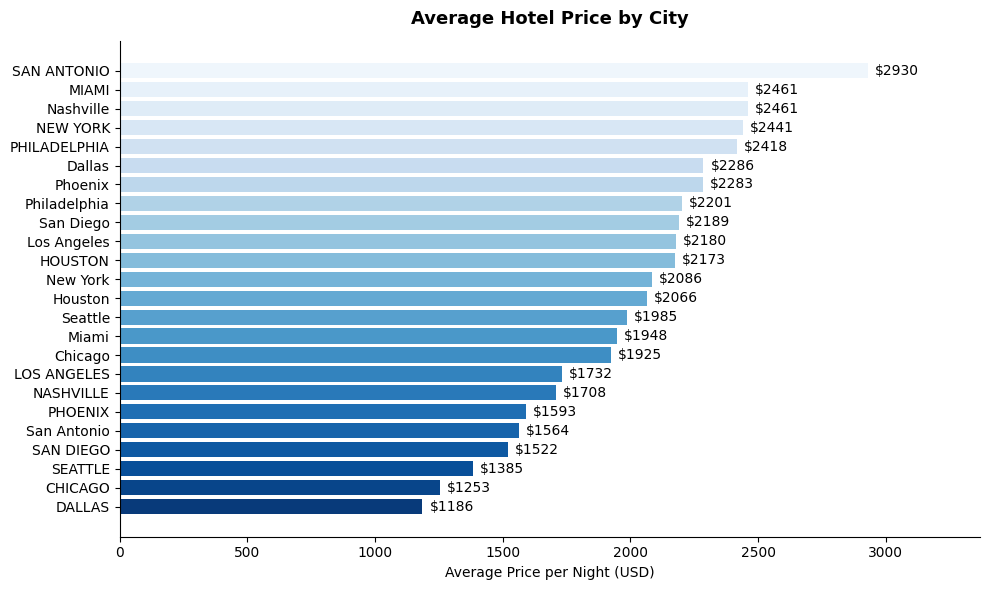

Most expensive city : SAN ANTONIO ($2930/night)
Most affordable city: DALLAS ($1186/night)


In [135]:
# groupby("city") groups all rows by city
# ["price_per_night"].mean() calculates the average price for each city
# sort_values() puts the most expensive city at the top
avg_price = (hotels.groupby("city")["price_per_night"]
             .mean()
             .sort_values(ascending=True))   # ascending=True → longest bar on top for horizontal charts

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(avg_price.index, avg_price.values,
               color=sns.color_palette("Blues_r", len(avg_price)))

# Add value labels at the end of each bar
ax.bar_label(bars, fmt="$%.0f", padding=5, fontsize=10)

ax.set_xlabel("Average Price per Night (USD)")
ax.set_title("Average Hotel Price by City", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, avg_price.max() * 1.15)   # extra space for labels
plt.tight_layout()
plt.show()

print("Most expensive city :", avg_price.idxmax(), f"(${avg_price.max():.0f}/night)")
print("Most affordable city:", avg_price.idxmin(), f"(${avg_price.min():.0f}/night)")


---
## 🔵 Chart 2 — Price vs Rating (Scatter Plot)
**Business question:** Does paying more guarantee a better experience?


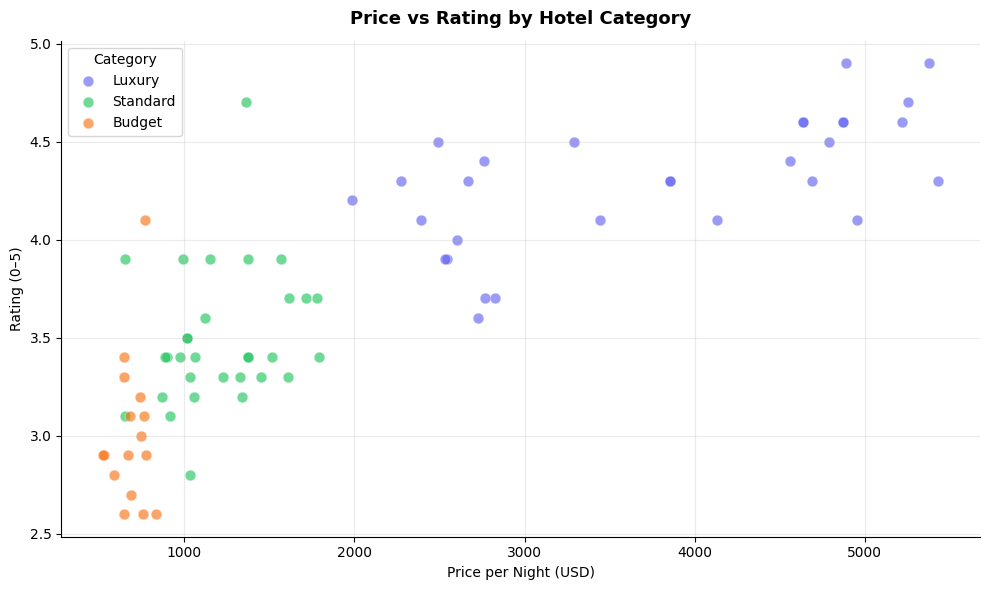

Pearson correlation (price vs rating): 0.812
Interpretation: values near 0 mean price does NOT strongly predict rating


In [136]:
# Scatter plot: each dot = one hotel
# x-axis = price, y-axis = rating
# Color = category (Budget / Standard / Luxury)
palette = {"Luxury": "#6366F1", "Standard": "#22C55E", "Budget": "#F97316"}

fig, ax = plt.subplots(figsize=(10, 6))
for cat, color in palette.items():
    subset = hotels[hotels["category"] == cat]
    ax.scatter(subset["price_per_night"], subset["rating"],
               label=cat, color=color, alpha=0.65, s=60, edgecolors="white", linewidth=0.4)

ax.set_xlabel("Price per Night (USD)")
ax.set_ylabel("Rating (0–5)")
ax.set_title("Price vs Rating by Hotel Category", fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Category")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Correlation coefficient: 1.0 = perfect positive, 0 = no relationship, -1.0 = negative
corr = hotels[["price_per_night", "rating"]].corr().iloc[0, 1]
print(f"Pearson correlation (price vs rating): {corr:.3f}")
print("Interpretation: values near 0 mean price does NOT strongly predict rating")


This scatter plot shows the relationship between hotel price (x-axis) and hotel rating (y-axis). Each dot represents one hotel, and the colors indicate different hotel categories.

Summary


*   Luxury hotels (blue) generally have the highest prices and higher ratings (around 4.0–4.9).
*   Standard hotels (green) have moderate prices with ratings mostly between 3.0 and 4.0.
*   Budget hotels (orange) have the lowest prices, but some still receive high ratings, showing that an

---
## 🥧 Chart 3 — Hotel Category Distribution
**Business question:** What is the hotel mix across all cities?


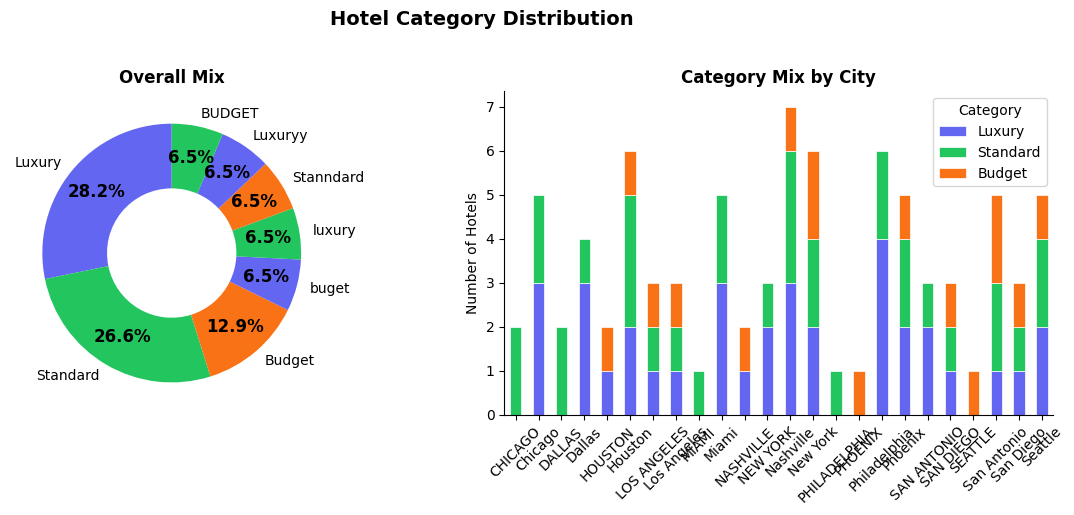

In [137]:
cat_counts = hotels["category"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Donut chart ─────────────────────────────────────────────────────────
colors_pie = ["#6366F1", "#22C55E", "#F97316"]
wedges, texts, autotexts = ax1.pie(
    cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
    colors=colors_pie, startangle=90,
    wedgeprops=dict(width=0.5),   # width < 1 creates the donut hole
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")
ax1.set_title("Overall Mix", fontsize=12, fontweight="bold")

# ── Right: Stacked bar by city ────────────────────────────────────────────────
# groupby two columns → size() counts hotels per (city, category) pair
# unstack() pivots 'category' into columns
city_cat = (hotels.groupby(["city", "category"])
            .size().unstack(fill_value=0)
            [["Luxury", "Standard", "Budget"]])
city_cat.plot(kind="bar", stacked=True, ax=ax2,
              color=colors_pie, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("")
ax2.set_ylabel("Number of Hotels")
ax2.set_title("Category Mix by City", fontsize=12, fontweight="bold")
ax2.legend(title="Category", loc="upper right")
ax2.tick_params(axis="x", rotation=45)

plt.suptitle("Hotel Category Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


The pie chart shows the overall distribution:
* Luxury: 42.1% (largest share)
* Standard: 29.8%
* Budget: 28.1%

The stacked bar chart compares the number of hotels in each category by city.
* Most cities have a mix of Luxury, Standard, and Budget hotels.
* The proportions vary slightly, but no single category completely dominates every city.

---
## 📦 Chart 4 — Price Distribution by Category (Box Plot)
**Business question:** How consistent is pricing within each hotel tier?


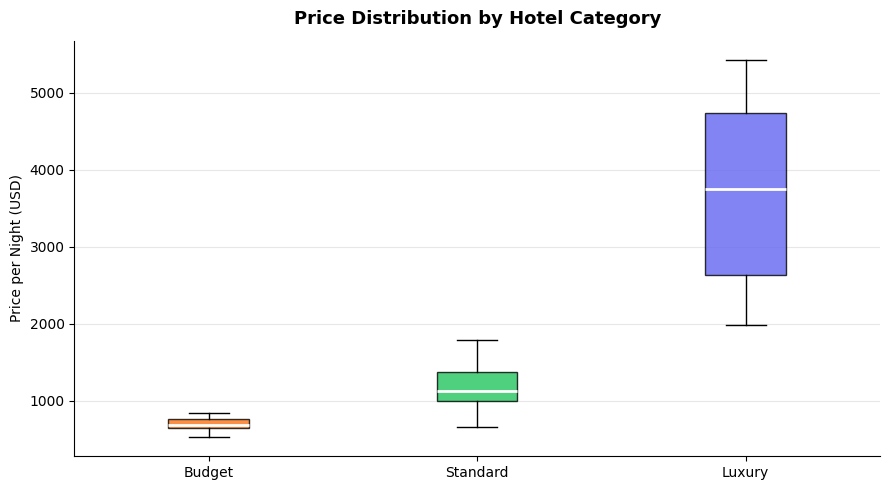

Median prices:
  Budget    : $684/night
  Standard  : $1120/night
  Luxury    : $3747/night


In [138]:
# Box plot shows:
#   box  = middle 50% of prices (Q1 to Q3)
#   line = median price
#   whiskers = range (excluding outliers)
#   dots = outlier prices
fig, ax = plt.subplots(figsize=(9, 5))
order = ["Budget", "Standard", "Luxury"]
colors = ["#F97316", "#22C55E", "#6366F1"]

bp = ax.boxplot(
    [hotels[hotels["category"] == c]["price_per_night"].dropna() for c in order],
    labels=order, patch_artist=True,
    medianprops=dict(color="white", linewidth=2)
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("Price per Night (USD)")
ax.set_title("Price Distribution by Hotel Category", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Median prices:")
for c in order:
    med = hotels[hotels["category"] == c]["price_per_night"].median()
    print(f"  {c:10}: ${med:.0f}/night")


A box plot shows the distribution of the data. It helps us compare the typical value, the variation, and identify outliers.

*  The white line shows the median (the typical price).
*  The box represents the middle 50% of the data. A taller box means the prices vary more.
*  The circles are outliers, which are unusually high or low prices.

**Summary**: This box plot compares hotel prices across three categories.
*   Luxury hotels have the highest prices and the widest price range.
*   Standard hotels have more consistent prices.
*   Budget hotels are generally cheaper but have a few unusually high prices (outliers).

---
## 📈 Chart 5 — Hotels by Year Opened (Histogram)
**Business question:** Are newer hotels rated higher than older ones?


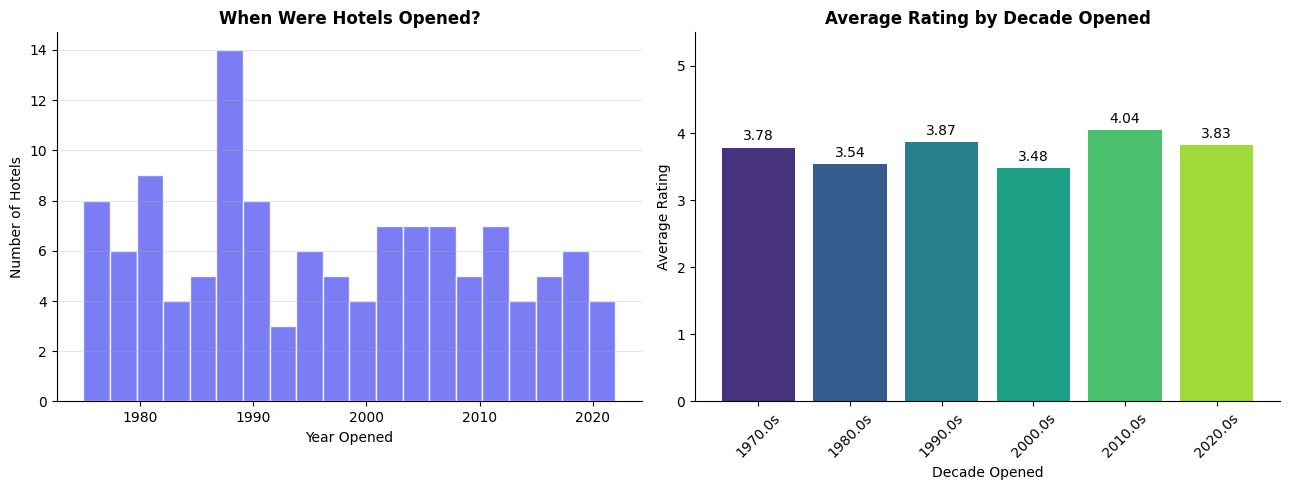

In [139]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Histogram ────────────────────────────────────────────────────────────
# bins=20 divides the year range into 20 equal buckets
ax1.hist(hotels["year_opened"], bins=20,
         color="#6366F1", edgecolor="white", alpha=0.85)
ax1.set_xlabel("Year Opened")
ax1.set_ylabel("Number of Hotels")
ax1.set_title("When Were Hotels Opened?", fontsize=12, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# ── Right: Decade vs average rating ──────────────────────────────────────────
# Integer division (//) rounds down to the nearest decade
# e.g. 1998 // 10 * 10 = 1990, then we add "s" → "1990s"
hotels["decade"] = (hotels["year_opened"] // 10 * 10).astype(str) + "s"
decade_rating = hotels.groupby("decade")["rating"].mean().sort_index()

bars = ax2.bar(decade_rating.index, decade_rating.values,
               color=sns.color_palette("viridis", len(decade_rating)))
ax2.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax2.set_xlabel("Decade Opened")
ax2.set_ylabel("Average Rating")
ax2.set_ylim(0, 5.5)
ax2.set_title("Average Rating by Decade Opened", fontsize=12, fontweight="bold")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


---
## 📋 Session Summary

### Part 1 — Cleaning Techniques Used
| Step | Problem | Fix |
|------|---------|-----|
| 2a | UPPERCASE cities | `str.title()` |
| 2b | "3 stars" string | `str.extract(r"(\d+)").astype(int)` |
| 2c | Category typos | `str.lower().map(cat_map)` |
| 2d | "1998.0" year | `str.extract(r"(\d{4})")` |
| 2e | "150 rooms" string | `str.extract(r"(\d+)").astype(int)` |
| 2f | Missing hotel name | `dropna(subset=)` |
| 2g | Duplicate hotel_id | `drop_duplicates(subset=)` |
| 3a | "USD 3200" price | `str.replace(r"[^\d.","")` |
| 3b | Rating > 5.0 | `df.loc[mask] = None` |
| 3c | yes/no/TRUE/FALSE | `str.lower().map()` |
| 3d | "350 reviews" | `str.extract(r"(\d+)")` |
| 3e | "15%" discount | `str.replace("%","").astype(float)` |
| 3f | Amenity separators | `str.replace(";",",")` |
| 4 | Two separate files | `pd.merge(how="inner")` |

### Part 2 — Charts Covered
| Chart | Type | Business Question |
|-------|------|-------------------|
| 1 | Horizontal bar | Which city is most expensive? |
| 2 | Scatter | Does price = higher rating? |
| 3 | Box plot | How consistent is pricing per tier? |
| 4 | Donut + Stacked bar | What is the hotel mix? |
| 5 | Histogram + Bar | Are newer hotels rated higher? |

---
> 🚀 **Day 29:** Build `db_agent` that queries `hotels.csv` to answer natural language questions like *"Find a luxury hotel in Miami with a pool under $4000/night"*
